# Option Pricing Library — Analysis Notebook

This notebook prices vanilla options using five methods and compares their accuracy, Greeks, and runtime.

**Baseline contract**

| Parameter | Value |
|-----------|-------|
| Option type | European / American put |
| Spot price $S_0$ | 100 |
| Strike $K$ | 100 |
| Maturity $T$ | 1 year |
| Risk-free rate $r$ | 5% |
| Volatility $\sigma$ | 20% |
| Grid upper bound $S_{\max}$ | 200 |
| FD spatial steps $M$ | 200 |
| FD time steps $N$ | 200 |
| Monte Carlo paths | 100,000 |

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from black_scholes import BlackScholesPricer
from finite_difference import FiniteDifferencePricer
from crank_nicolson import CrankNicolsonPricer
from monte_carlo import MonteCarloPricer

pd.set_option('display.float_format', '{:.6f}'.format)

## 2. Shared Parameters

In [2]:
params = dict(S0=100, K=100, T=1.0, r=0.05, sigma=0.2)
fd_params = dict(**params, S_max=200, M=200, N=200)

## 3. European Put — All Methods

Price and Greeks for a European put under all five methods.
Black-Scholes is the exact reference; all other methods are compared against it.

In [3]:
np.random.seed(42)

bs  = BlackScholesPricer("put", **params).solve()

# Note: explicit scheme requires very small dt for stability (CFL condition).
# Using M=50 to satisfy the stability limit at N=200.
fde = FiniteDifferencePricer("put", "european", "explicit",
                              S_max=200, M=50, N=200, **params).solve()

fdi = FiniteDifferencePricer("put", "european", "implicit",
                              **fd_params).solve()

cn  = CrankNicolsonPricer("put", "european",
                           **fd_params).solve()

mc  = MonteCarloPricer("put", n_paths=100_000, **params).solve()

bs_price = bs.result["price"]
print(f"Black-Scholes reference price: {bs_price:.6f}")

Black-Scholes reference price: 5.573526


In [4]:
pricers = [
    ("Black-Scholes (exact)",     bs),
    ("Explicit FD (M=50)",        fde),
    ("Implicit FD (M=N=200)",     fdi),
    ("Crank-Nicolson (M=N=200)",  cn),
    ("Monte Carlo (100k paths)",  mc),
]

rows = []
for name, p in pricers:
    r = p.result
    rows.append({
        "Method":      name,
        "Price":       r["price"],
        "Error vs BS": abs(r["price"] - bs_price) if name != "Black-Scholes (exact)" else 0.0,
        "Delta":       r["delta"],
        "Gamma":       r["gamma"],
        "Theta":       r["theta"],
        "Time (s)":    r["time_taken"],
    })

df = pd.DataFrame(rows).set_index("Method")
print("\nEuropean Put — Pricing Summary")
print("=" * 80)
print(df.to_string())


European Put — Pricing Summary
                            Price  Error vs BS     Delta    Gamma     Theta  Time (s)
Method                                                                               
Black-Scholes (exact)    5.573526     0.000000 -0.363169 0.018762 -1.657880  0.006503
Explicit FD (M=50)       5.538440     0.035086 -0.364085 0.018841 -1.680345  0.021928
Implicit FD (M=N=200)    5.566400     0.007126 -0.363324 0.018808 -1.666591  1.497596
Crank-Nicolson (M=N=200) 5.571061     0.002465 -0.363232 0.018769 -1.659126  0.944595
Monte Carlo (100k paths) 5.574186     0.000659 -0.362675 0.022522 -1.658819  1.584858


**Reading the table.** Crank-Nicolson achieves the smallest error despite using the same grid as Implicit FD, reflecting its second-order temporal accuracy. Monte Carlo error is stochastic — it will vary slightly across runs even with the seed set, because different methods use random draws at different points.

## 4. Option Value and Greeks Plots

Each pricer exposes a `.plot()` method that shows option value, Delta, Gamma, and Theta across the full spatial grid. Monte Carlo adds two extra panels: simulated paths and the terminal price distribution.

Black-Scholes (closed form)


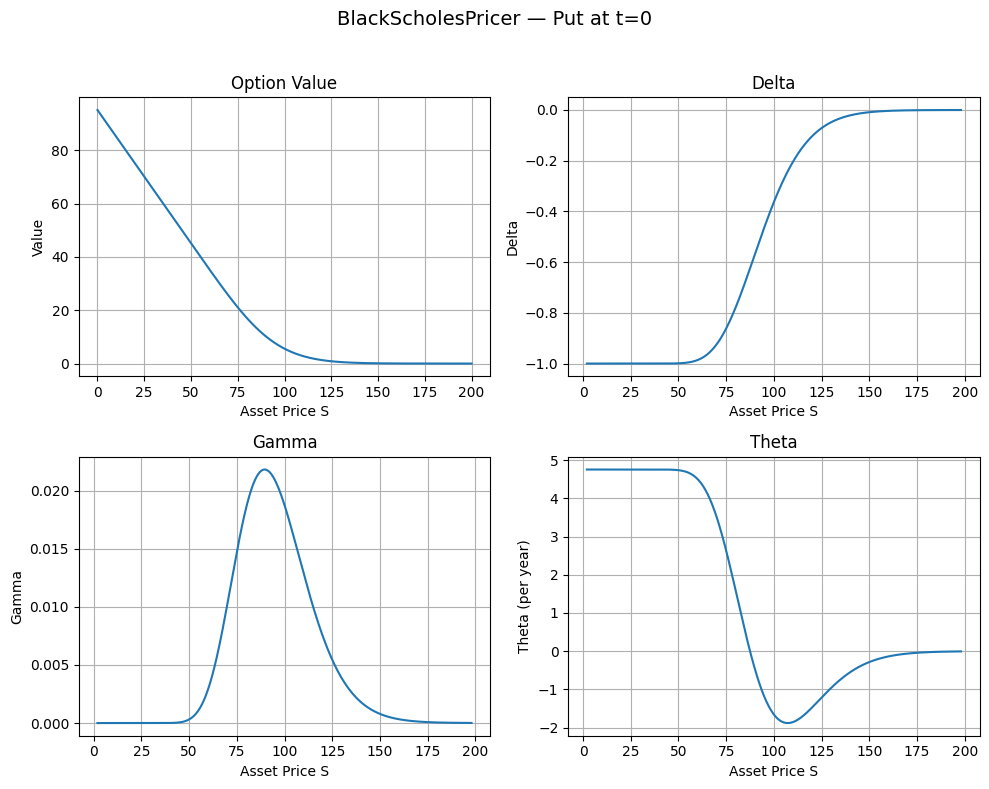

In [5]:
print("Black-Scholes (closed form)")
bs.plot()

Implicit Finite Difference


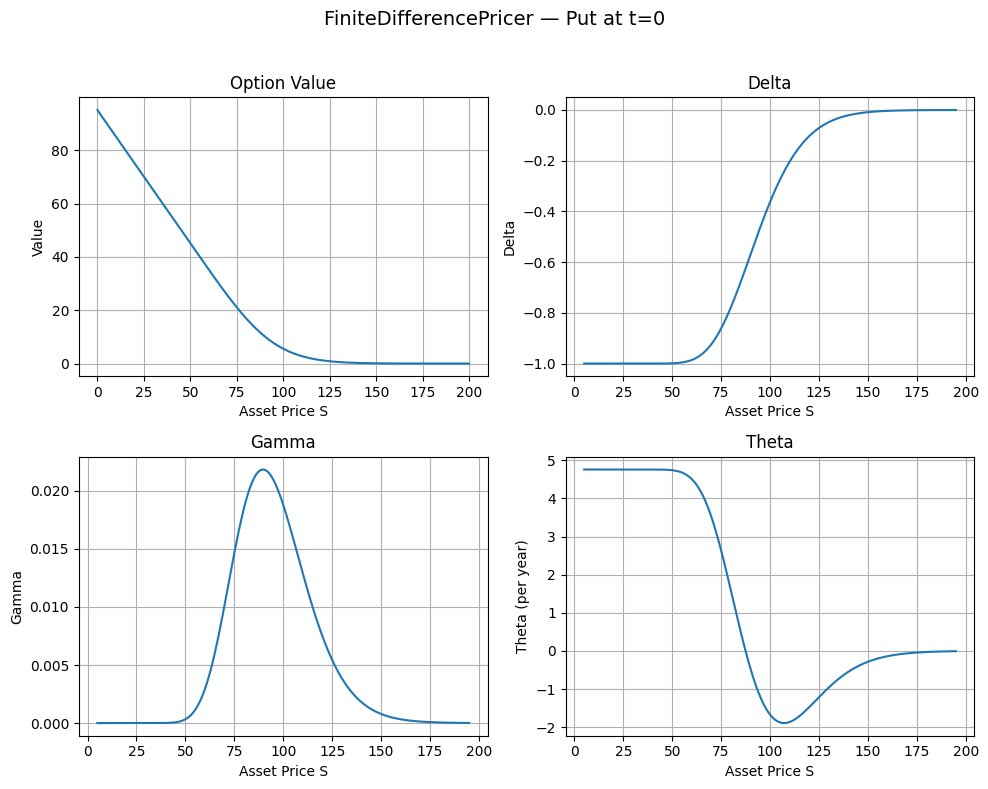

In [6]:
print("Implicit Finite Difference")
fdi.plot()

Crank-Nicolson


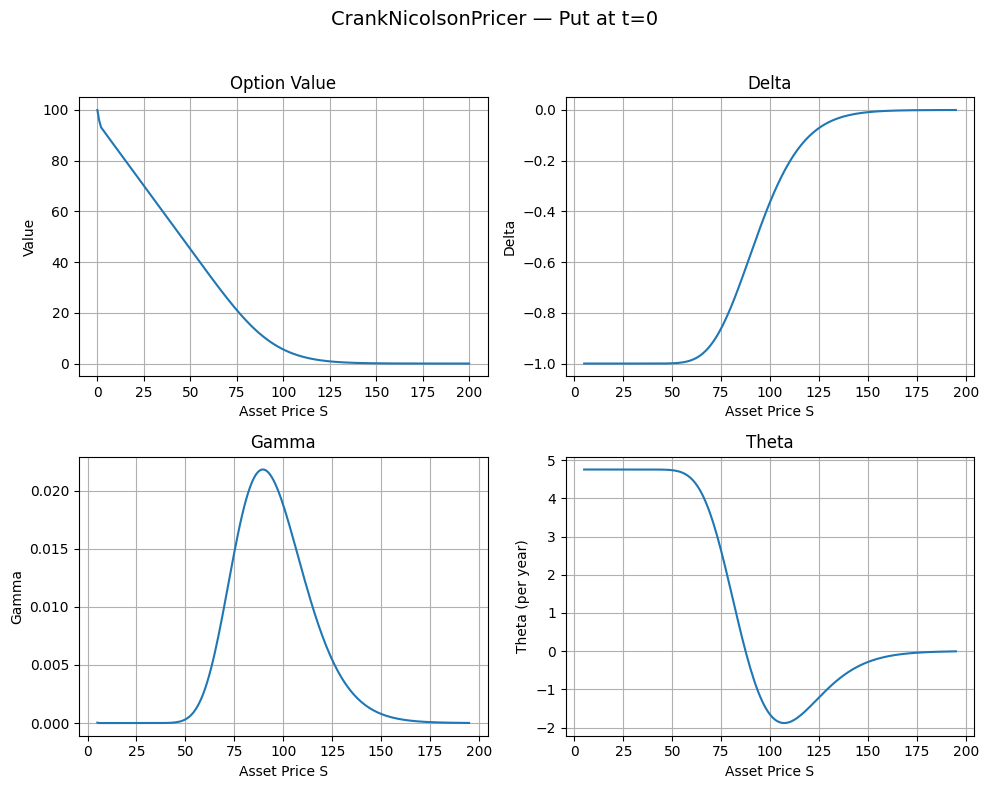

In [7]:
print("Crank-Nicolson")
cn.plot()

Monte Carlo (6-panel including paths and terminal distribution)


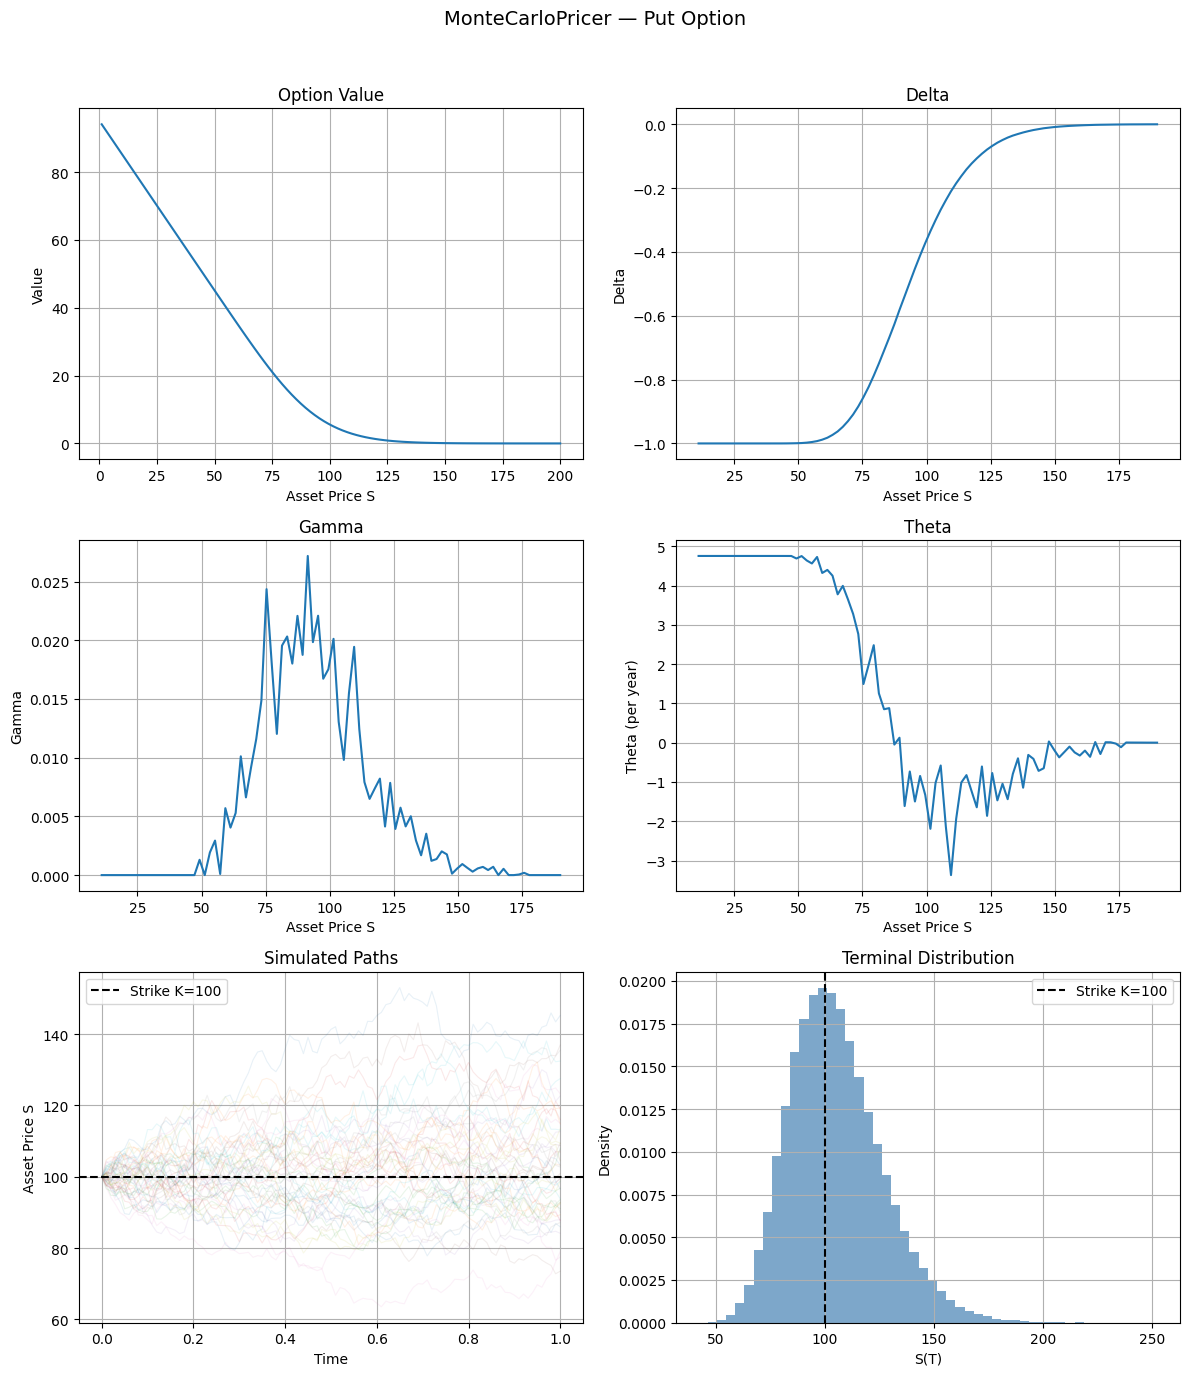

In [8]:
print("Monte Carlo (6-panel including paths and terminal distribution)")
mc.plot()

## 5. American Put — Early Exercise Premium

American puts allow early exercise. When the stock falls far enough it is optimal to exercise immediately — the free boundary problem has no closed-form solution, which is why numerical methods are necessary.

The **early exercise premium** is the price difference between the American and European put.

In [9]:
fdi_am = FiniteDifferencePricer("put", "american", "implicit",
                                 **fd_params).solve()

cn_am  = CrankNicolsonPricer("put", "american",
                              **fd_params).solve()

eu_price_fdi = fdi.result["price"]
eu_price_cn  = cn.result["price"]

am_rows = [
    {
        "Method":          "Implicit FD",
        "European Put":    eu_price_fdi,
        "American Put":    fdi_am.result["price"],
        "Early Exercise Premium": fdi_am.result["price"] - eu_price_fdi,
    },
    {
        "Method":          "Crank-Nicolson",
        "European Put":    eu_price_cn,
        "American Put":    cn_am.result["price"],
        "Early Exercise Premium": cn_am.result["price"] - eu_price_cn,
    },
]

df_am = pd.DataFrame(am_rows).set_index("Method")
print("\nAmerican vs European Put")
print("=" * 60)
print(df_am.to_string())

print(f"\nThe two methods agree on the premium to within: "
      f"{abs(fdi_am.result['price'] - cn_am.result['price']):.4f}")


American vs European Put
                European Put  American Put  Early Exercise Premium
Method                                                            
Implicit FD         5.566400      6.080604                0.514204
Crank-Nicolson      5.571061      6.087419                0.516358

The two methods agree on the premium to within: 0.0068


**Interpretation.** The early exercise premium is positive — the right to exercise early and invest the strike at the risk-free rate adds value. Both solvers use PSOR (Projected Successive Over-Relaxation) to enforce the constraint $V \geq \text{payoff}$ at each grid point. Their agreement to within a few thousandths of a dollar provides mutual validation.

## 6. Convergence Analysis

How quickly does each method converge to the exact Black-Scholes price as resolution increases?

- **Implicit FD**: first-order in time, $\mathcal{O}(\delta t)$
- **Crank-Nicolson**: second-order in time, $\mathcal{O}(\delta t^2)$ — should converge ~4× faster per step
- **Monte Carlo**: $\mathcal{O}(N^{-1/2})$ — standard statistical rate

In [10]:
# --- Implicit FD convergence (vary N, fix M=200)
N_values_fd = [10, 25, 50, 100, 200, 500]
fd_errors, fd_times = [], []

for N in N_values_fd:
    start = time.time()
    p = FiniteDifferencePricer(
        "put", "european", "implicit", S_max=200, M=200, N=N, **params
    ).solve()
    fd_times.append(time.time() - start)
    fd_errors.append(abs(p.result["price"] - bs_price))
    print(f"  FD  N={N:<5}  price={p.result['price']:.6f}  "
          f"error={fd_errors[-1]:.6f}  time={fd_times[-1]:.4f}s")

  FD  N=10     price=5.478535  error=0.094991  time=1.7316s
  FD  N=25     price=5.533898  error=0.039628  time=1.2314s
  FD  N=50     price=5.552453  error=0.021074  time=1.1829s
  FD  N=100    price=5.561748  error=0.011778  time=1.2605s
  FD  N=200    price=5.566400  error=0.007126  time=1.3620s
  FD  N=500    price=5.569193  error=0.004334  time=1.7663s


In [11]:
# --- Crank-Nicolson convergence (smaller N range — converges very fast)
N_values_cn = [5, 10, 15, 20, 30, 40, 50, 75, 100]
cn_errors, cn_times = [], []

for N in N_values_cn:
    start = time.time()
    p = CrankNicolsonPricer(
        "put", "european", S_max=200, M=200, N=N, **params
    ).solve()
    cn_times.append(time.time() - start)
    cn_errors.append(abs(p.result["price"] - bs_price))
    print(f"  CN  N={N:<5}  price={p.result['price']:.6f}  "
          f"error={cn_errors[-1]:.6f}  time={cn_times[-1]:.4f}s")

  CN  N=5      price=5.930441  error=0.356914  time=0.5510s
  CN  N=10     price=5.452888  error=0.120638  time=0.5315s
  CN  N=15     price=5.615202  error=0.041676  time=0.5337s
  CN  N=20     price=5.558234  error=0.015293  time=0.5321s
  CN  N=30     price=5.570600  error=0.002926  time=0.6263s
  CN  N=40     price=5.571193  error=0.002333  time=0.6224s
  CN  N=50     price=5.571154  error=0.002373  time=0.6142s
  CN  N=75     price=5.571099  error=0.002427  time=0.6764s
  CN  N=100    price=5.571080  error=0.002447  time=0.7437s


In [12]:
# --- Monte Carlo convergence (average over multiple runs to reduce noise)
path_values = [100, 250, 500, 1_000, 2_500, 5_000, 10_000, 25_000, 50_000]
mc_errors, mc_times = [], []
n_repeats = 10

for n in path_values:
    errors = []
    start  = time.time()
    for _ in range(n_repeats):
        p = MonteCarloPricer("put", n_paths=n, **params).solve()
        errors.append(abs(p.result["price"] - bs_price))
    mc_times.append(time.time() - start)
    mc_errors.append(np.mean(errors))
    print(f"  MC  paths={n:<8}  mean_error={mc_errors[-1]:.6f}  "
          f"time={mc_times[-1]:.4f}s")

  MC  paths=100       mean_error=0.695361  time=0.1174s
  MC  paths=250       mean_error=0.433522  time=0.1294s
  MC  paths=500       mean_error=0.405350  time=0.1626s
  MC  paths=1000      mean_error=0.195937  time=0.2161s
  MC  paths=2500      mean_error=0.166653  time=0.3651s
  MC  paths=5000      mean_error=0.075329  time=0.7018s
  MC  paths=10000     mean_error=0.042819  time=1.2841s
  MC  paths=25000     mean_error=0.037538  time=3.1235s
  MC  paths=50000     mean_error=0.027637  time=6.7205s


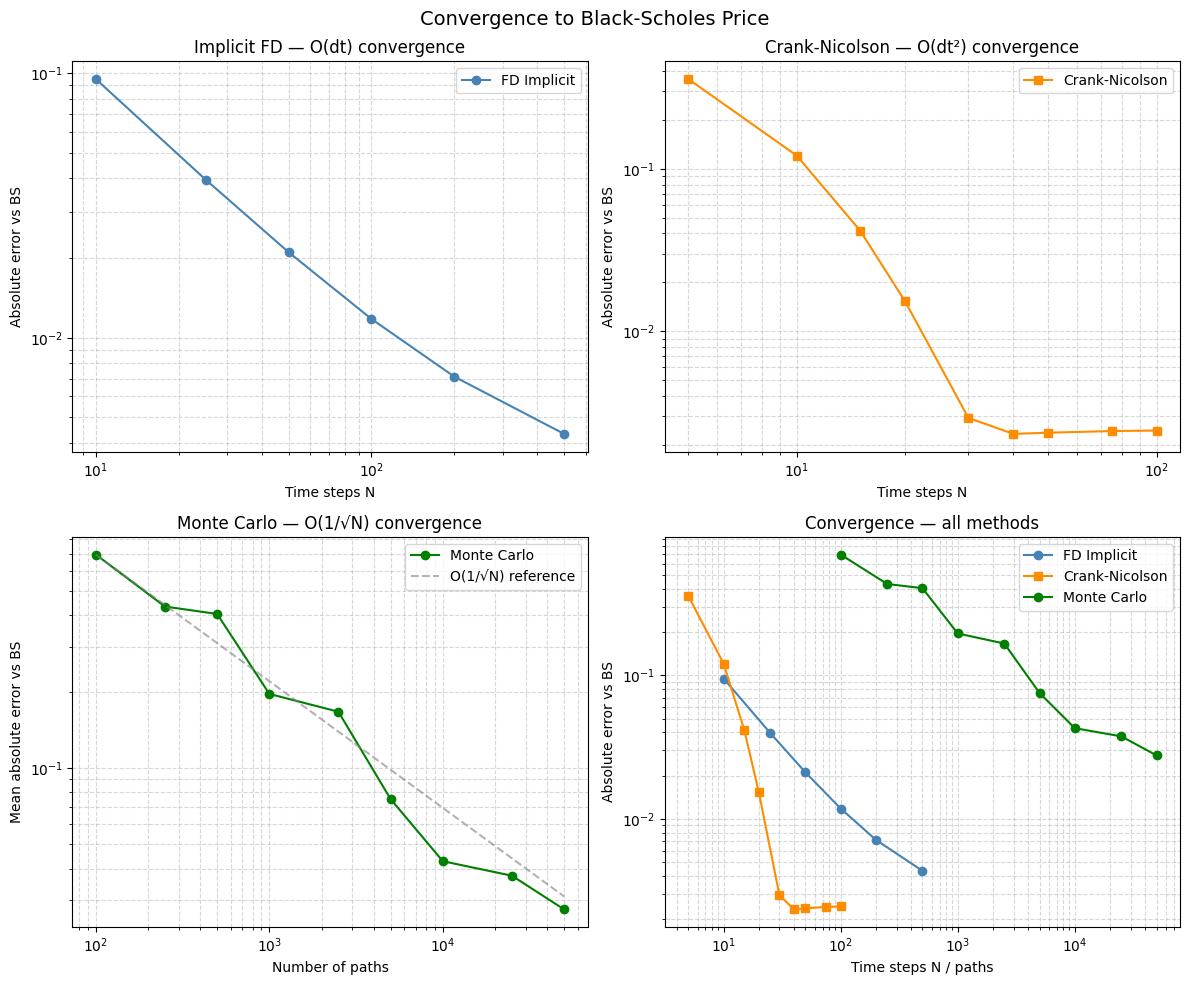

Saved: convergence.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Convergence to Black-Scholes Price", fontsize=14)

# Implicit FD
axes[0, 0].loglog(N_values_fd, fd_errors, "o-", color="steelblue", label="FD Implicit")
axes[0, 0].set_title("Implicit FD — O(dt) convergence")
axes[0, 0].set_xlabel("Time steps N")
axes[0, 0].set_ylabel("Absolute error vs BS")
axes[0, 0].legend()
axes[0, 0].grid(True, which="both", linestyle="--", alpha=0.5)

# CN
axes[0, 1].loglog(N_values_cn, cn_errors, "s-", color="darkorange", label="Crank-Nicolson")
axes[0, 1].set_title("Crank-Nicolson — O(dt²) convergence")
axes[0, 1].set_xlabel("Time steps N")
axes[0, 1].set_ylabel("Absolute error vs BS")
axes[0, 1].legend()
axes[0, 1].grid(True, which="both", linestyle="--", alpha=0.5)

# Monte Carlo
axes[1, 0].loglog(path_values, mc_errors, "o-", color="green", label="Monte Carlo")
# Overlay theoretical O(1/sqrt(N)) reference line
ref = mc_errors[0] * np.sqrt(path_values[0]) / np.sqrt(np.array(path_values))
axes[1, 0].loglog(path_values, ref, "--", color="gray", alpha=0.6, label="O(1/√N) reference")
axes[1, 0].set_title("Monte Carlo — O(1/√N) convergence")
axes[1, 0].set_xlabel("Number of paths")
axes[1, 0].set_ylabel("Mean absolute error vs BS")
axes[1, 0].legend()
axes[1, 0].grid(True, which="both", linestyle="--", alpha=0.5)

# Combined comparison
axes[1, 1].loglog(N_values_fd,  fd_errors, "o-", color="steelblue",  label="FD Implicit")
axes[1, 1].loglog(N_values_cn,  cn_errors, "s-", color="darkorange", label="Crank-Nicolson")
axes[1, 1].loglog(path_values,  mc_errors, "o-", color="green",      label="Monte Carlo")
axes[1, 1].set_title("Convergence — all methods")
axes[1, 1].set_xlabel("Time steps N / paths")
axes[1, 1].set_ylabel("Absolute error vs BS")
axes[1, 1].legend()
axes[1, 1].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: convergence.png")

**Reading the convergence plots.** On a log-log scale, a straight line with slope $-1$ corresponds to $\mathcal{O}(\delta t)$ convergence, and slope $-2$ to $\mathcal{O}(\delta t^2)$. Crank-Nicolson's line should be steeper than Implicit FD, hitting machine-precision levels at far fewer time steps. Monte Carlo follows the $\mathcal{O}(N^{-1/2})$ reference closely — halving the error requires quadrupling the path count.

## 7. SOR Omega Sensitivity

The SOR/PSOR solver has a relaxation parameter $\omega$. $\omega = 1$ recovers Gauss-Seidel; $1 < \omega < 2$ gives over-relaxation. Here we measure iteration counts and runtime across a range of $\omega$ values.

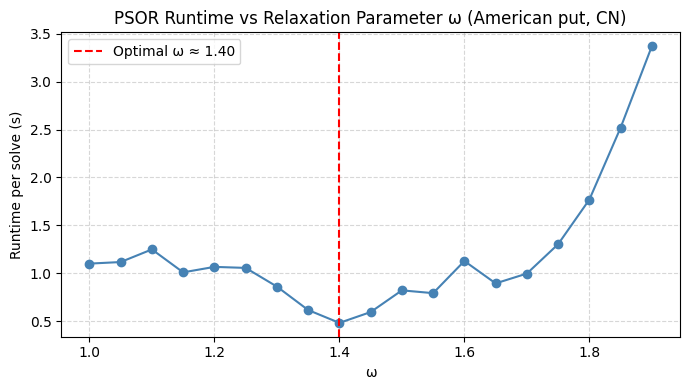

Optimal omega: 1.40


In [14]:
from solvers import SORSolver

# Build a representative tridiagonal system from CN at M=200, N=200
# Solve it repeatedly with different omega values and count iterations manually

omega_values = np.arange(1.0, 1.95, 0.05)
omega_times  = []

for omega in omega_values:
    start = time.time()
    for _ in range(5):   # 5 solves to get a stable timing
        CrankNicolsonPricer(
            "put", "american", S_max=200, M=200, N=50,
            omega=omega, **params
        ).solve()
    omega_times.append((time.time() - start) / 5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(omega_values, omega_times, "o-", color="steelblue")
ax.axvline(omega_values[np.argmin(omega_times)], color="red",
           linestyle="--", label=f"Optimal ω ≈ {omega_values[np.argmin(omega_times)]:.2f}")
ax.set_title("PSOR Runtime vs Relaxation Parameter ω (American put, CN)")
ax.set_xlabel("ω")
ax.set_ylabel("Runtime per solve (s)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("omega_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Optimal omega: {omega_values[np.argmin(omega_times)]:.2f}")

## 8. Greeks Comparison

Side-by-side comparison of Delta, Gamma, and Theta at $S_0 = 100$ across all methods.

In [15]:
greeks_rows = []
for name, p in pricers:
    r = p.result
    greeks_rows.append({
        "Method":  name,
        "Price":   r["price"],
        "Delta":   r["delta"],
        "Gamma":   r["gamma"],
        "Theta":   r["theta"],
    })

df_greeks = pd.DataFrame(greeks_rows).set_index("Method")
print("\nGreeks at S0 = 100 — European Put")
print("=" * 65)
print(df_greeks.to_string())


Greeks at S0 = 100 — European Put
                            Price     Delta    Gamma     Theta
Method                                                        
Black-Scholes (exact)    5.573526 -0.363169 0.018762 -1.657880
Explicit FD (M=50)       5.538440 -0.364085 0.018841 -1.680345
Implicit FD (M=N=200)    5.566400 -0.363324 0.018808 -1.666591
Crank-Nicolson (M=N=200) 5.571061 -0.363232 0.018769 -1.659126
Monte Carlo (100k paths) 5.574186 -0.362675 0.022522 -1.658819


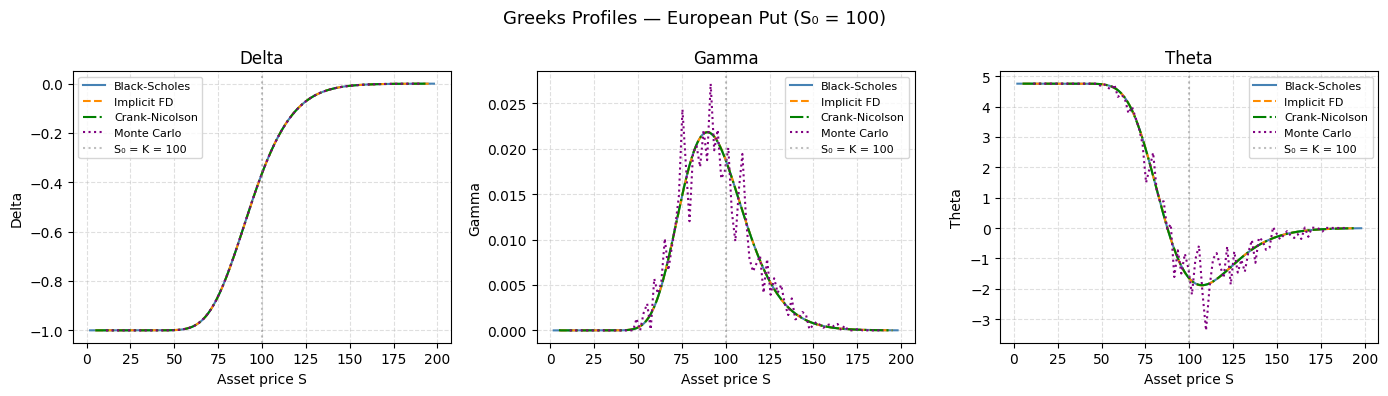

Saved: greeks_comparison.png


In [16]:
# Plot Delta and Gamma profiles across the spatial grid
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Greeks Profiles — European Put (S₀ = 100)", fontsize=13)

pad = 5

plot_pricers = [
    ("Black-Scholes",    bs,  "steelblue",  "-"),
    ("Implicit FD",      fdi, "darkorange", "--"),
    ("Crank-Nicolson",   cn,  "green",      "-."),
    ("Monte Carlo",      mc,  "purple",     ":"),
]

for label, greek_key, ax_idx in [("Delta", "delta_grid", 0),
                                  ("Gamma", "gamma_grid", 1),
                                  ("Theta", "theta_grid", 2)]:
    for name, p, color, ls in plot_pricers:
        S = p.result["S_grid"]
        g = p.result[greek_key]
        # Handle both 1D and 2D grids
        if hasattr(g, 'ndim') and g.ndim == 1:
            axes[ax_idx].plot(S[pad:-pad], g[pad:-pad],
                              label=name, color=color, linestyle=ls, linewidth=1.5)
        else:
            axes[ax_idx].plot(S[pad:-pad], g[pad:-pad],
                              label=name, color=color, linestyle=ls, linewidth=1.5)
    axes[ax_idx].axvline(100, color="gray", linestyle=":", alpha=0.5, label="S₀ = K = 100")
    axes[ax_idx].set_title(label)
    axes[ax_idx].set_xlabel("Asset price S")
    axes[ax_idx].set_ylabel(label)
    axes[ax_idx].grid(True, linestyle="--", alpha=0.4)
    axes[ax_idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig("greeks_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: greeks_comparison.png")

**Interpretation.**
- **Delta** ranges from $-1$ (deep in-the-money put) to $0$ (far out-of-the-money), passing through $-0.5$ at the strike. All methods agree closely.
- **Gamma** peaks near the strike and decays away from it — the hedge requires most frequent rebalancing when the option is at-the-money.
- **Theta** is most negative near the strike; time value erodes fastest for at-the-money options.

## 9. Summary Table

In [17]:
summary = pd.DataFrame([
    {"Method": "Black-Scholes",   "European": "Yes", "American": "No",
     "Accuracy": "Exact",            "Stability": "N/A",          "Speed": "Fastest"},
    {"Method": "Explicit FD",     "European": "Yes", "American": "Yes",
     "Accuracy": "O(dt)",            "Stability": "Conditional",  "Speed": "Slow"},
    {"Method": "Implicit FD",     "European": "Yes", "American": "Yes",
     "Accuracy": "O(dt)",            "Stability": "Unconditional","Speed": "Moderate"},
    {"Method": "Crank-Nicolson",  "European": "Yes", "American": "Yes",
     "Accuracy": "O(dt²)",           "Stability": "Unconditional","Speed": "Moderate"},
    {"Method": "Monte Carlo",     "European": "Yes", "American": "No",
     "Accuracy": "O(1/√N)",          "Stability": "N/A",          "Speed": "Moderate"},
]).set_index("Method")

print("\nMethod Comparison Summary")
print("=" * 80)
print(summary.to_string())


Method Comparison Summary
               European American Accuracy      Stability     Speed
Method                                                            
Black-Scholes       Yes       No    Exact            N/A   Fastest
Explicit FD         Yes      Yes    O(dt)    Conditional      Slow
Implicit FD         Yes      Yes    O(dt)  Unconditional  Moderate
Crank-Nicolson      Yes      Yes   O(dt²)  Unconditional  Moderate
Monte Carlo         Yes       No  O(1/√N)            N/A  Moderate


**Key takeaways.**

1. For European options where speed and precision matter, Black-Scholes is unbeatable — it is exact and instantaneous.
2. For American-style contracts, Crank-Nicolson with PSOR is the best balance of accuracy and stability — it converges in $\mathcal{O}(\delta t^2)$ and is unconditionally stable.
3. Monte Carlo is the natural extension for path-dependent or high-dimensional contracts not covered here; it demonstrates correct $\mathcal{O}(N^{-1/2})$ convergence and a rigorous Greek estimation framework via Common Random Numbers and the pathwise Delta estimator.
4. The pure-Python SOR loops are the main bottleneck. Replacing them with vectorised NumPy or Numba would reduce finite difference runtimes by one to two orders of magnitude.